In [1]:
# Cell 1
import pandas as pd, sys; sys.path.append("..")
from src.ml_model import train_all_models, plot_roc_curves, shap_analysis, save_best_model

df = pd.read_csv("../data/raw/sessions.csv")



In [2]:
# Cell 2 — Train
results, X_test, y_test = train_all_models(df)

Logistic Regression       | CV AUC: 0.6484 | Test AUC: 0.5446
Random Forest             | CV AUC: 0.6471 | Test AUC: 0.5621
Gradient Boosting         | CV AUC: 0.6433 | Test AUC: 0.5599


c:\Users\Shrey\Desktop\codes_proj\customer_journey_analyzer\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [11:52:11] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\Shrey\Desktop\codes_proj\customer_journey_analyzer\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [11:52:11] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\Shrey\Desktop\codes_proj\customer_journey_analyzer\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [11:52:11] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\Shrey\Desktop\codes_proj\customer_journey_analyzer\venv\Lib\site-packages\xgboost\training.py:200: U

XGBoost                   | CV AUC: 0.6362 | Test AUC: 0.5644


c:\Users\Shrey\Desktop\codes_proj\customer_journey_analyzer\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [11:52:11] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


FileNotFoundError: [Errno 2] No such file or directory: '../outputs/figures/roc_curves.png'

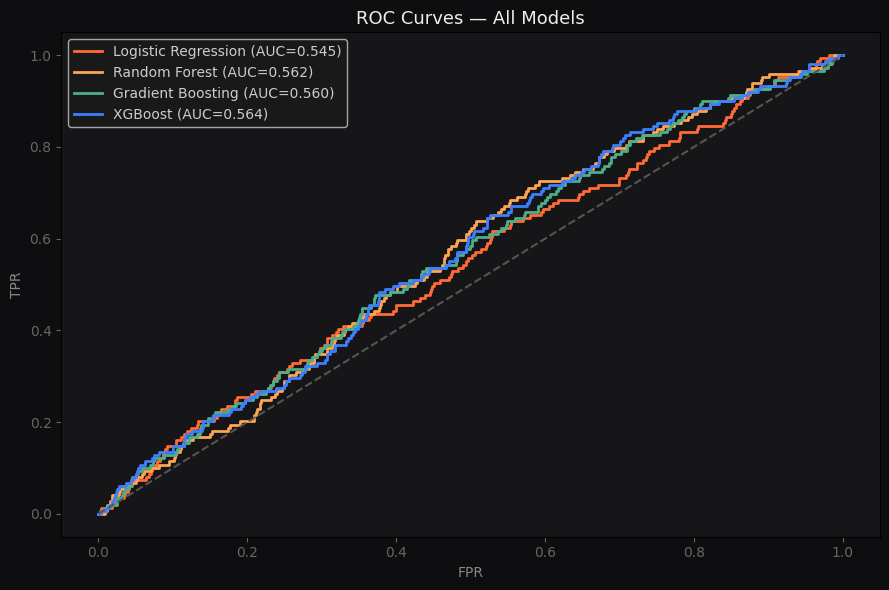

In [3]:
# Cell 3 — ROC comparison
plot_roc_curves(results, save_path="../outputs/figures/roc_curves.png")

In [5]:
import os
os.makedirs("../outputs/models", exist_ok=True)
os.makedirs("../outputs/figures", exist_ok=True)
os.makedirs("../outputs/reports", exist_ok=True)
print("Folders created!")

Folders created!


In [6]:
# Cell 4 — Best model & SHAP
best_name, best_res = save_best_model(results, path="../outputs/models/best_model.pkl")
print(f"\nBest: {best_name}")
print(pd.DataFrame(best_res["report"]).T.round(3))

Saved best model: XGBoost (AUC=0.5644)

Best: XGBoost
              precision  recall  f1-score   support
0                 0.953   0.781     0.858  2851.000
1                 0.060   0.268     0.098   149.000
accuracy          0.755   0.755     0.755     0.755
macro avg         0.507   0.525     0.478  3000.000
weighted avg      0.909   0.755     0.821  3000.000


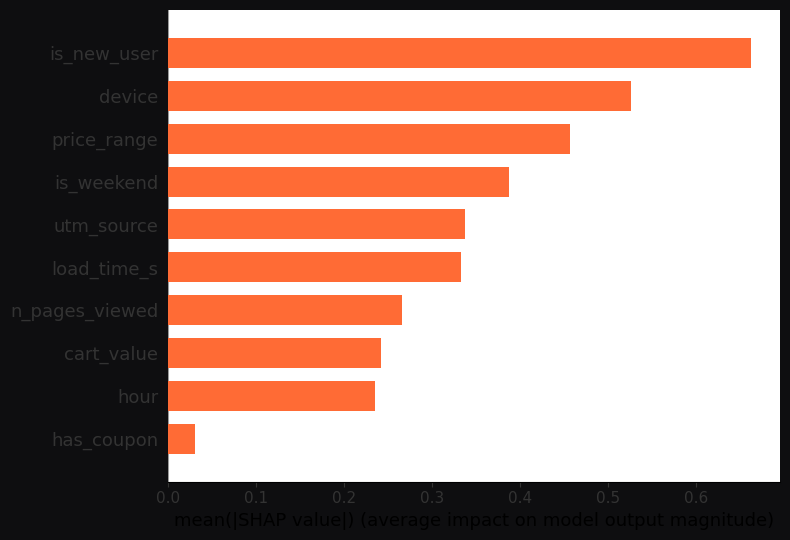

In [7]:
# Cell 5 — SHAP feature importance (run only on tree-based best model)
if "XGBoost" in best_name or "Forest" in best_name:
    from src.ml_model import preprocess, FEATURES
    X_proc = preprocess(df)[FEATURES]
    shap_analysis(best_res["model"], X_proc.sample(500, random_state=42),
                  save_path="../outputs/figures/shap_importance.png")